# Module 8 — The Agentic Pipeline: State, Evaluation, and What Comes Next


---


## The Journey So Far

We started with a bare LLM call — a recipe name in, a time category out. By module 7, that same classifier accepts a photo of a recipe card and returns a personalized time estimate that accounts for the user's cooking history, the specific techniques required, and a fine-tuned adapter that improved accuracy on hard cases *(built in Module 5 — if you completed that assignment, bring your adapter\'s accuracy numbers to this comparison)*.

Here is a quick run down of things we have covered and the artifacts that you would have created as part of this course


### Week-by-Week Timeline


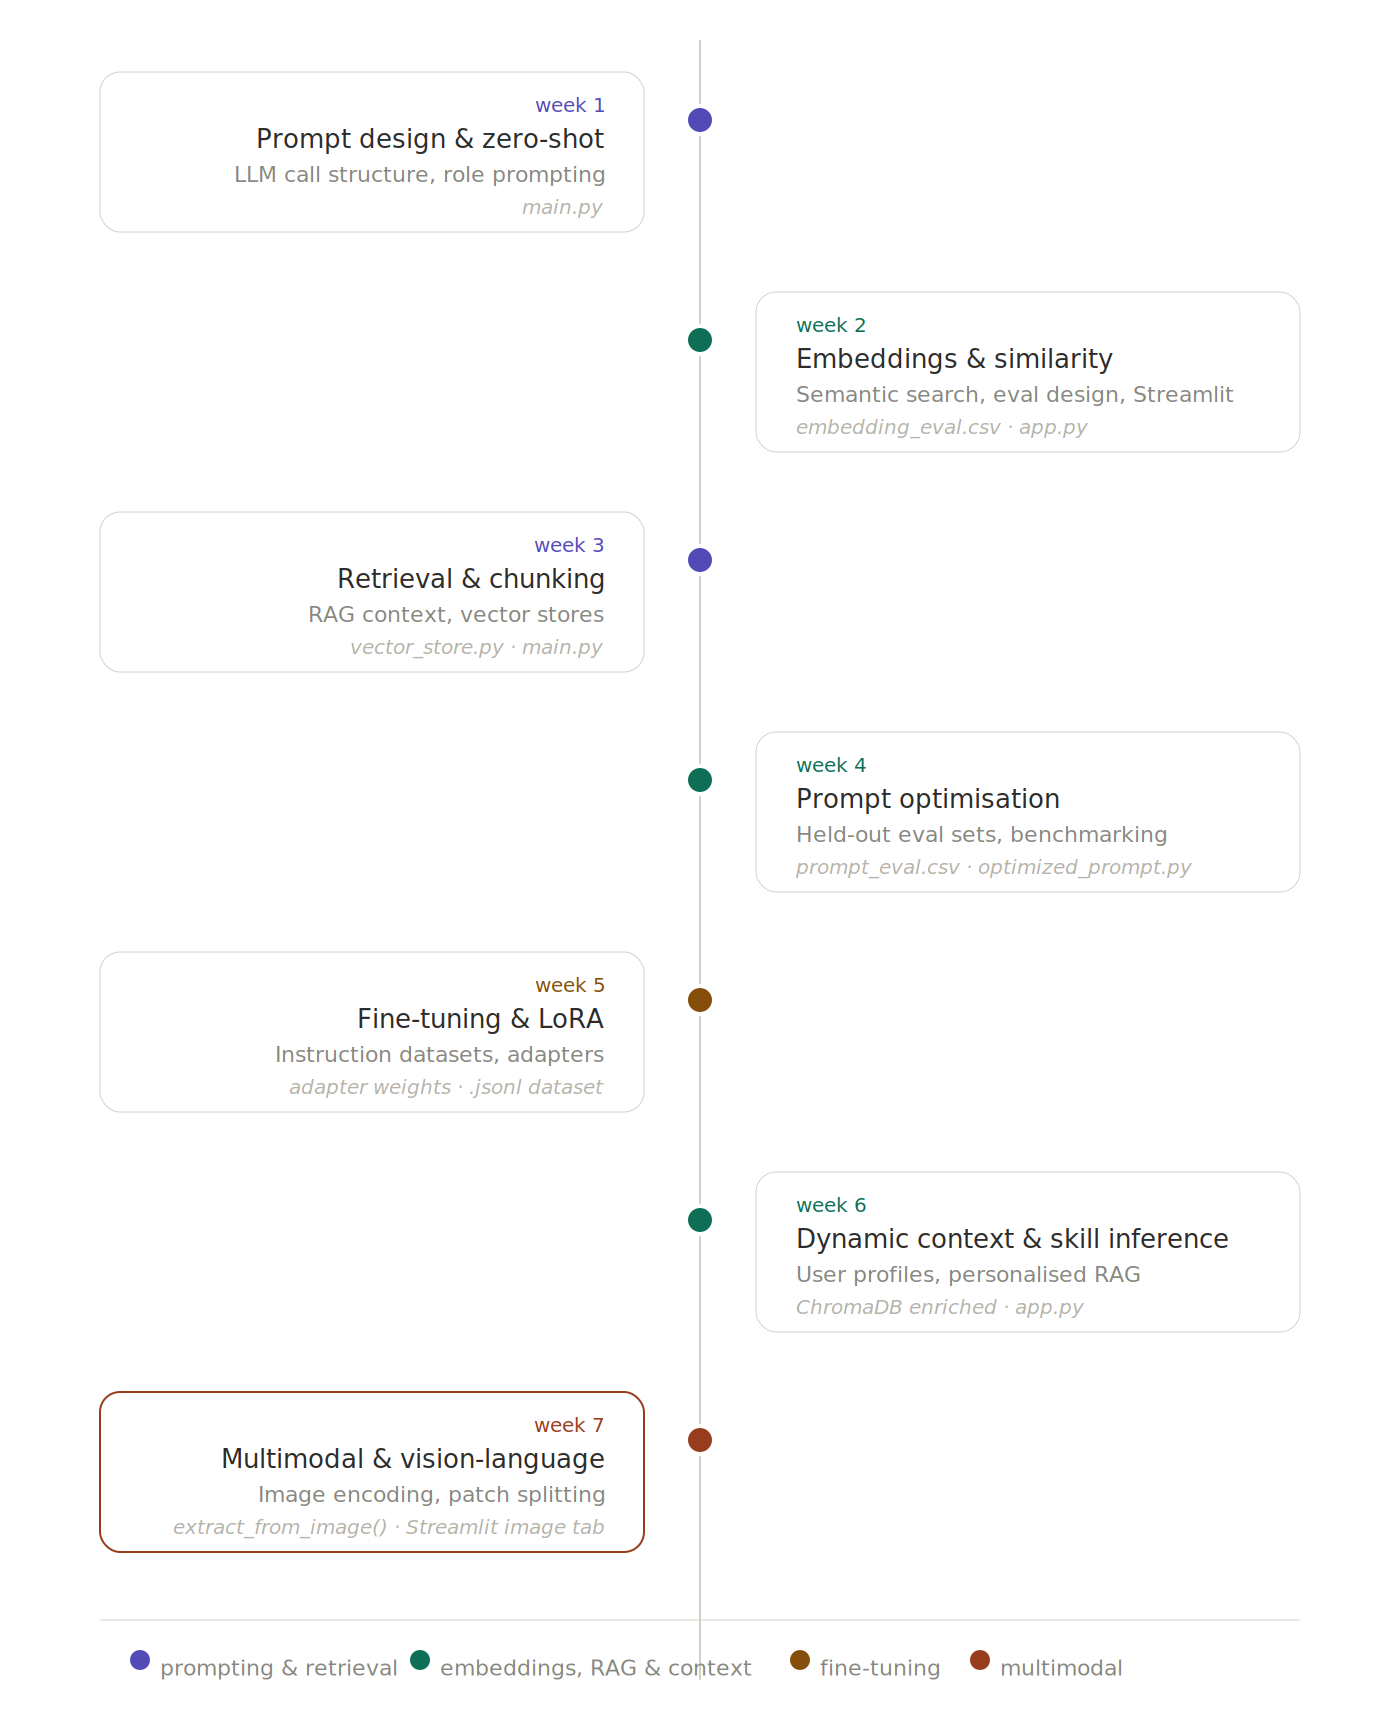

---
## Module 8 — The Agentic State Machine *(Not to Be Confused with SSM Architectures Like Mamba — Here We Use the Classical Control-Theory Sense of States, Transitions, and Observations)*


### What Is a State Machine?

> **Terminology note:** "State machine" here refers to the classical concept of states, transitions, and observations — not the "state space model" (SSM) architectures like S4 or Mamba used for sequence modeling in ML. If you search for "state space model," you will find the ML sequence-modeling literature; this section uses the term in its original control-theory sense.

In the broader sense of intelligent systems, a **state space model** is a framework for describing how a system moves through a space
of possible situations in response to actions.

Formally, a state space system has four components:

| Component | Symbol | What it means in our context |
|-----------|--------|-------------------------------|
| **States** | S | The set of situations the system can be in — e.g., `IDLE`, `EXTRACTING`, `CLASSIFYING` |
| **Actions** | A | The set of things the system can do — e.g., call `extract_recipe()`, call `classify_recipe()` |
| **Transition function** | T(s, a) → s' | Given the current state and an action, what is the next state? |
| **Observations** | O | What the system receives from the environment — e.g., the image bytes, the user's cooking history |

many pipelines can be modeled as a state machine. The question is whether the transitions are *pre-programmed* (your pipeline: always EXTRACT → CONTEXT_LOADED → CLASSIFY, in that order) or *decided at runtime by the model* (an agent: the model looks at the current state and picks the
next action from a set of available tools).

Understanding this distinction is the key to reading the current LLM landscape.


### Our Pipeline as a Formal State Machine

<!-- DIAGRAM: state-machine-pipeline.png
     Circular state diagram. Seven nodes arranged in a ring:
     IDLE → INPUT_RECEIVED → EXTRACT → CONTEXT_LOADED → CLASSIFY → RESPOND → IDLE
     Each arrow is labeled with the trigger. The EXTRACT node has a dashed bypass arrow
     directly to CONTEXT_LOADED labeled "text input (no extraction needed)".
     Each node is color-coded by pipeline layer (week number). -->

| State | What it means | Trigger to next state | Who decides |
|-------|--------------|----------------------|-------------|
| `IDLE` | Waiting for input | User submits text or image | User |
| `INPUT_RECEIVED` | Input type determined | Route: image → `EXTRACT`; text → `CONTEXT_LOADED` | Builder (if/else) |
| `EXTRACT` | Vision step — image → structured recipe JSON | `extract_recipe(image_path)` returns successfully | Builder (always runs for images) |
| `CONTEXT_LOADED` | Skill inferred, technique chunks retrieved | `infer_skill()` + `retrieve_technique()` complete | Builder (always runs) |
| `CLASSIFY` | Time category assigned with personalized context | `classify_recipe()` returns A, B, or C | Builder (always runs) |
| `RESPOND` | Personalized response returned | Response rendered in Streamlit | Builder (always runs) |
| `IDLE` | Ready for next input | — | — |

Notice the last column: every transition is decided by the builder (you, in this case). The system always takes the same path through the same states in the same order. There is no branching on *content* — only on *type* (image vs. text at `INPUT_RECEIVED`).

This is what makes the pipeline **deterministic**: given the same input, it always executes the
same sequence of function calls.


### Structured Output as the Transition Contract

What allows one state to pass its result to the next state reliably? **Structured output.**

When `extract_recipe()` returns a schema-validated object:

```
{
  "recipe_name": "Carbonara",
  "ingredients": ["spaghetti", "guanciale", "eggs", "pecorino", "black pepper"],
  "directions": ["Boil pasta...", "Render guanciale...", "Mix eggs and cheese...", ...]
}
```

...the `CONTEXT_LOADED` state can immediately call `infer_skill(recipe_name=..., ingredients=...)`
without any parsing, guessing, or error handling for unexpected output format.

Without structured output, transitions are brittle:

| Transition | With structured output | Without structured output |
|------------|----------------------|---------------------------|
| EXTRACT → CONTEXT_LOADED | `recipe.recipe_name` is always a string | Must parse free text; may be `None`, truncated, or in wrong language |
| CONTEXT_LOADED → CLASSIFY | `context.skill_level` is always `"beginner"`, `"intermediate"`, or `"advanced"` | Must handle `"I think they're pretty good at cooking"` or empty string |
| CLASSIFY → RESPOND | `result.time_category` is always `"A"`, `"B"`, or `"C"` | Must handle `"The answer is B, maybe"` or a full paragraph |

This is why Pydantic models, JSON schemas, and constrained generation are not just conveniences —
they are the **interface contracts** between states. In a production agentic system, every tool
returns a typed, validated object. The agent's state machine is only as reliable as its contracts.


### From Pipeline to Agent: One Change

The one thing that turns a deterministic pipeline into an agent is **who decides the transitions.**

In our pipeline, you (the builder) hardcode the transitions. The system always runs:
`EXTRACT → CONTEXT_LOADED → CLASSIFY → RESPOND`. There is no way for the pipeline to say
"I don't think I should classify this — I need more information first."

An agent replaces the hardcoded transition logic with a model that **reasons about what to do next**:

| | Deterministic Pipeline (what we built) | Agent (what this becomes) |
|-|----------------------------------------|--------------------------|
| **Transitions** | Pre-programmed by the builder | Decided by model at runtime |
| **Sequence** | Always EXTRACT → CONTEXT → CLASSIFY → RESPOND | Model picks next action from available tools |
| **Branching** | Only on input type (image vs. text) | On content: can retry, backtrack, request clarification |
| **Tools** | Fixed function calls in fixed order | Named tools the model can invoke in any order |
| **Predictability** | Fully deterministic, easy to debug | Non-deterministic, requires trajectory logging |

The pattern that formalises this is **ReAct** (Reason + Act):

```
while goal_not_achieved:
    thought  = model.reason(current_state, available_tools, goal)
    action   = model.select_tool(thought)
    result   = action.execute()
    current_state = update(current_state, result)
```


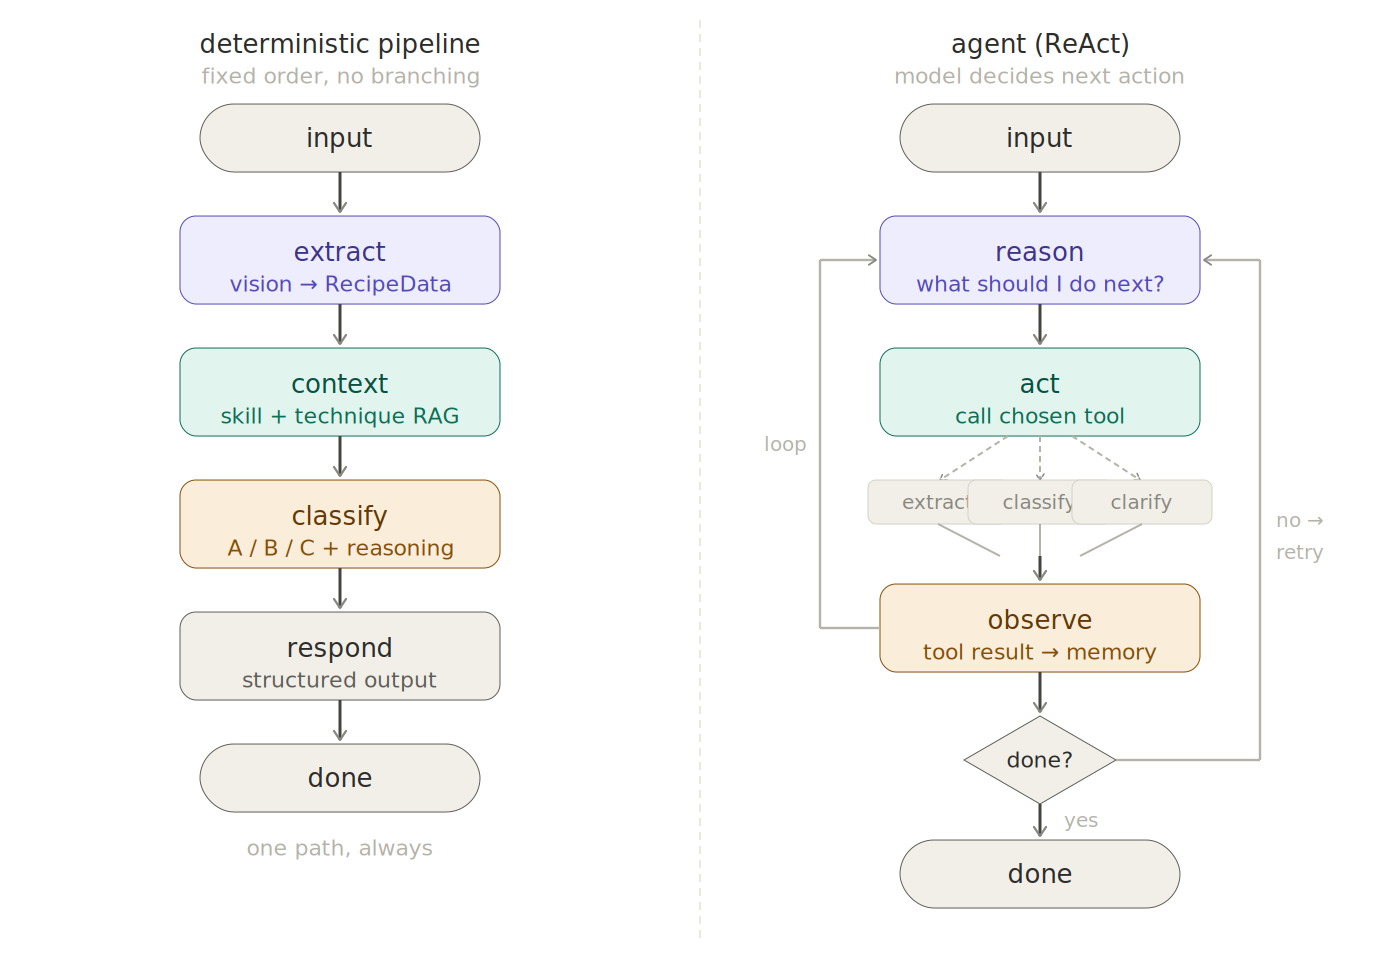


Our pipeline is a single, deterministic pass through this loop.
A real agent runs the loop multiple times, with the model choosing the next step each time.

The mental model transfers directly: **states, transitions, input/output contracts**.
The only difference is who decides the transitions — the builder or the model.


### Extending to a Chat Interface

Our current pipeline is **stateless between calls**: each invocation of `classify_from_image()`
is independent. It doesn't remember the previous turn, can't answer follow-up questions, and
can't accumulate context across a conversation.

A chat interface introduces a new state dimension: **conversation memory**.

<!-- DIAGRAM: state-machine-chat.png
     Extended state machine. The original ring (IDLE → INPUT_RECEIVED → EXTRACT →
     CONTEXT_LOADED → CLASSIFY → RESPOND → IDLE) is shown on the left.
     On the right, a new `CONVERSATION_ACTIVE` state sits between RESPOND and IDLE.
     A `FOLLOW_UP` arrow from CONVERSATION_ACTIVE re-enters the ring at CONTEXT_LOADED
     (bypassing EXTRACT for text follow-ups). A `MEMORY_UPDATE` arrow from RESPOND
     points to a `MEMORY` cylinder before returning to CONVERSATION_ACTIVE.
     A `SESSION_END` arrow from CONVERSATION_ACTIVE exits to IDLE. -->

What changes in the state machine:

| New element | What it adds |
|-------------|-------------|
| `CONVERSATION_ACTIVE` state | The system knows it's in a multi-turn session; doesn't reset to `IDLE` between turns |
| Memory store | Conversation history, previous classifications, user corrections — persisted across turns |
| `MEMORY_UPDATE` transition | After each `RESPOND`, write the exchange to memory before waiting for next input |
| `FOLLOW_UP` path | Re-enters pipeline at `CONTEXT_LOADED` for text follow-ups, skipping `EXTRACT` |
| Clarification branch | New path: model can respond with a question instead of a classification if input is ambiguous |

The key insight: adding a chat interface doesn't change the core classification states —
it **wraps them** in a new outer state machine that manages conversation flow.
This is the same pattern used by frameworks like LangGraph: inner graphs (tools, pipelines)
nested inside outer graphs (conversation loops, orchestration logic).

> **Practical note:** Not every transition needs to become the model's decision. Depending on
> your problem statement, you might keep some transitions deterministic — for example, always
> running extraction for images, or always updating memory after each turn. The value of the
> agentic design isn't to make everything dynamic; it's to identify *which* transitions genuinely
> benefit from model judgment and make only those flexible. A pipeline that is 80% deterministic
> and 20% agentic is often more reliable — and easier to debug — than one where the model decides
> everything.


---
## Evaluating Agentic Systems


### Why Traditional Evaluation Breaks

The eval approach we've used — run predictions on a labeled CSV, compute accuracy — works for
the classification layer in isolation. It breaks down for the pipeline as a whole.

| | Traditional ML eval | Agentic system eval |
|-|---------------------|---------------------|
| **Unit** | Single input → single output | Multi-step trajectory: input → action₁ → obs₁ → action₂ → ... → output |
| **Determinism** | Same input always produces same output | Model may take different paths to the same goal |
| **Metric** | Accuracy, F1, BLEU | Task completion, trajectory efficiency, tool use correctness, robustness |
| **Eval set** | Static: labeled pairs, frozen | Dynamic: distribution shifts as the system handles new situations |
| **Failure modes** | Wrong label | Silent failure at one step corrupts all downstream steps |
| **Ground truth** | Human-labeled expected output | Harder: what is the "correct" trajectory, not just the correct answer? |


### Four Dimensions of Evaluation

For an agentic pipeline like ours, evaluation has four dimensions:


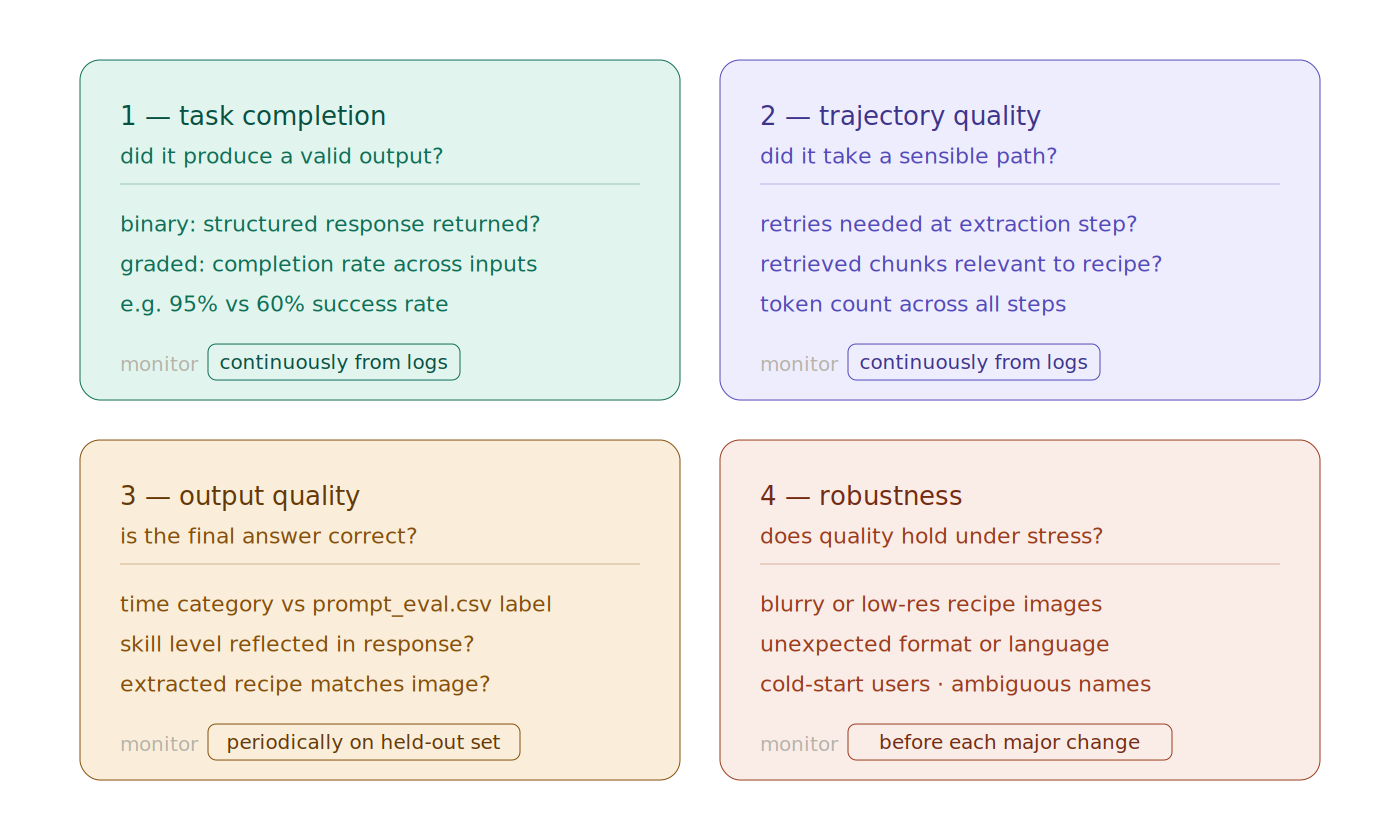


**1. Task completion** — Did the system produce a valid final output for the given input?
- Binary: did `classify_from_image()` return a structured response with a time category?
- Graded: did it complete for 95% of inputs, or 60%?

**2. Trajectory quality** — Did it take a sensible path to get there?
- Did extraction succeed on the first try, or require retries?
- Were the retrieved technique chunks relevant to the recipe being classified?
- How many tokens were consumed across all steps?

**3. Output quality** — Is the final answer actually correct and useful?
- Does the time category match the expected label (from your `prompt_eval.csv` (generated in Module 4) benchmark)?
- Does the personalized response incorporate the user's skill level appropriately?
- For vision inputs: does the extracted recipe match what's in the image?

**4. Robustness** — Does quality hold under challenging inputs?
- Blurry or low-resolution recipe images
- Recipes in an unexpected format or language
- Users with no prior history (cold-start)
- Ambiguous recipe names that could map to multiple time categories

In practice, you monitor dimensions 1 and 2 continuously (they're cheap to compute from logs),
run dimension 3 periodically on a held-out benchmark (it requires labeled data), and test
dimension 4 on a curated adversarial set before each major change.


### Three Evaluation Strategies

**LLM-as-judge**

Use a stronger model to evaluate the output of a weaker model. Example: after `gemma2:2b`
classifies a recipe, ask `gemma4:latest` to score the classification:

```
You are evaluating a recipe time classification system.

Recipe: "Quick weeknight pasta carbonara"
Retrieved context: beginner skill level, technique: "rendering guanciale"
Classification: Category A (under 30 minutes)
Reasoning: "Simple ingredient list, standard technique, short cook time"

Is this classification plausible given the recipe and context? Score 1-3 and explain.
```

Advantages: no labeled data required, cheap at scale, catches reasoning failures not just wrong labels.
Limitations: the judge model has its own biases; calibrate against human ratings before trusting it.

**Trajectory evaluation**

Log every step of the pipeline — function called, inputs, outputs, duration, token count.
Evaluate the logged trajectory, not just the final output.

A correct answer achieved after 3 retries with 2,000 tokens is a worse trajectory than a
correct answer on the first try with 400 tokens, even if both "pass" a label-accuracy eval.

Trajectory eval also catches the silent failure mode: an extraction that returns a structurally
valid but semantically wrong recipe (fields present, wrong content) will pass a schema check
but fail a trajectory eval that compares extracted ingredient count to image ground truth.

**Human evaluation**

For the final mile — whether the output is actually *useful* to a real user — nothing replaces
human judgement. Structured human eval: show the evaluator the input, the output, and a rubric;
record a 1-5 score and a free-text note. Expensive and slow, but the gold standard for
calibrating automated evals.

The practical workflow: LLM-as-judge + trajectory eval run on every request (automated, continuous).
Human eval runs weekly on a sample of 20–50 requests flagged by the automated evals as borderline.


### Tooling: From OpenTelemetry to Observability Platforms

The foundation for observing any LLM pipeline is **OpenTelemetry** — the open standard for
structured telemetry data. The same standard used for distributed system observability
(Jaeger, Zipkin, Datadog) applies directly to LLM pipelines.

**OpenLLMetry** (by Traceloop) extends OpenTelemetry with LLM-specific attributes: prompt text,
completion text, token counts, model name, and cost. It wraps your existing pipeline calls with
minimal instrumentation — one decorator or context manager per function — and emits structured
spans that any OpenTelemetry-compatible backend can consume.

```python
from opentelemetry import trace
tracer = trace.get_tracer(__name__)

def classify_recipe(recipe, user_context):
    with tracer.start_as_current_span("classify_recipe") as span:
        span.set_attribute("recipe.name", recipe["recipe_name"])
        span.set_attribute("llm.model_name", "gemma2:2b")
        # ... your existing classification code ...
        span.set_attribute("llm.output", result.category)
        return result
```

The key property: **instrument once, route anywhere**. Because your spans follow the OpenTelemetry
standard, you can send them to any compatible backend — LangSmith, Arize Phoenix, a local Jaeger
instance, or a cloud provider's observability stack — without changing your pipeline code.

What a span records per pipeline step:

| Attribute | What it captures |
|-----------|------------------|
| `span.name` | Function or step name (`extract_recipe`, `classify_recipe`) |
| `llm.prompts` | Full prompt sent to the model (system + user messages) |
| `llm.completions` | Full model response |
| `llm.token_count.total` | Token consumption (input + output) |
| `llm.model_name` | Model identifier (`gemma2:2b`, `gemma4:latest`) |
| `span.duration` | Wall-clock latency for this step |
| `retrieval.documents` | Retrieved chunks + similarity scores (for RAG steps) |
| `span.status` | Success or error, with exception details |

**Observability platforms** (LangSmith, Arize Phoenix, and others) build on top of this standard.
They consume your OpenTelemetry traces and add visualisation, search, annotation, and evaluation
features on top. The choice of platform is a tooling preference, not an architectural decision —
what matters is that your spans are instrumented correctly.

<!-- DIAGRAM: langsmith-trace-tree.png
     LangSmith UI mock. Left panel: project "recipe-classifier", 3 traces listed with
     timestamp, latency (1.2s / 3.4s / 0.9s), and pass/fail badge.
     Right panel: expanded trace tree for the 3.4s trace (marked failing).
     Root: classify_from_image (3.4s). Four children:
       extract_recipe (1.1s, green) — output: {"recipe_name": "Carbonara", ...}
       infer_skill (0.3s, green) — output: {"skill": "intermediate"}
       retrieve_techniques (0.2s, green) — output: [chunk1, chunk2]
       classify_recipe (1.8s, red) — output: null, error: "JSON parse failed"
     Annotation panel on right: human feedback thumbs-down, note "extraction was correct
     but classifier timed out". -->


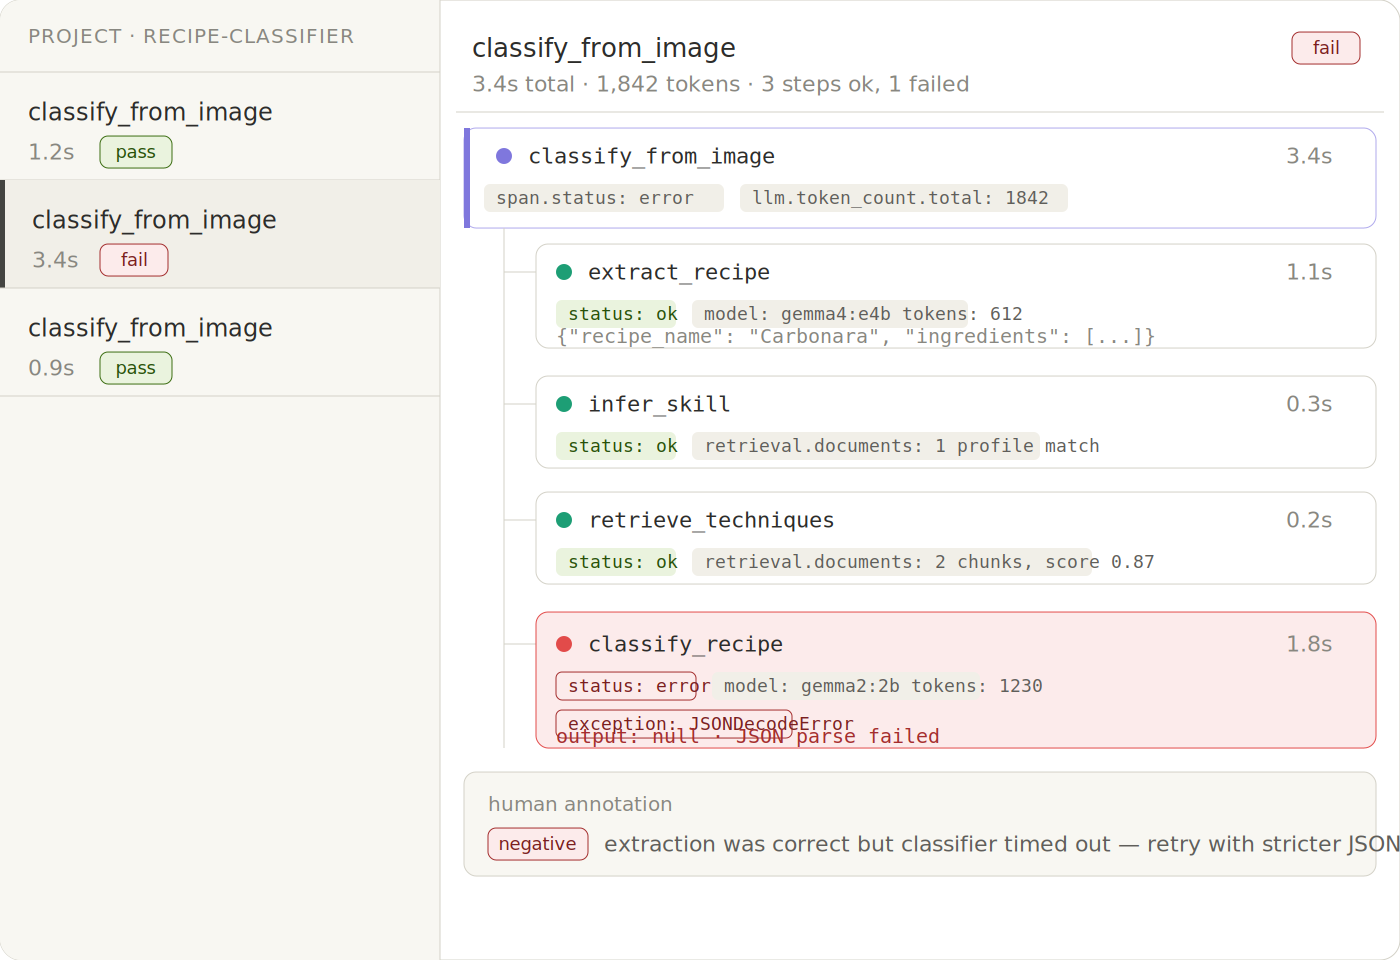

### Observability Tools in Practice

Once you have trace spans flowing from your pipeline, any observability platform gives you
the same core capabilities. The specific tool matters less than the pattern.

**What your traces enable:**

1. **Debug a failure** — navigate to the failing span, see the exact prompt and exact response.
   The bug is usually immediately visible: a malformed JSON extraction, a retrieved chunk from
   the wrong domain, a prompt that hit the context limit.

2. **Curate an eval dataset** — tag any trace as interesting (failure, edge case, good example).
   Your growing collection of tagged traces becomes a regression test suite: run your pipeline
   against the same set on every future change and see what moved.

3. **Run automated evals** — attach an LLM-as-judge evaluator to your dataset. The tool runs
   the evaluator on every new entry and tracks scores over time — showing the effect of each
   prompt or model change.

4. **Compare experiments** — run the same dataset through two versions of your pipeline
   (different prompt, different model, different retrieval strategy) and compare side-by-side
   which performs better on each example.

**For RAG pipelines specifically** — some platforms add embedding visualisation: they plot query
embeddings and chunk embeddings in 2D so you can see which queries land near the right chunks
and which fall into empty space (retrieval failures).

<!-- DIAGRAM: arize-phoenix-umap.png
     2D UMAP scatter plot. Blue dots: technique chunk embeddings (dense cluster centre-left).
     Green dots: query embeddings for recent requests (mostly near blue cluster).
     Red dots: 4 query embeddings far from any chunk cluster, labeled "retrieval failures".
     Legend: Technique chunks / Queries (matched) / Queries (unmatched).
     Sidebar: "Retrieval failure rate: 12% (4/33 queries)" with alert badge. -->

**Shared foundation:** all of these platforms are built on OpenTelemetry traces.
Instrument once with OpenLLMetry; switch or add tools without changing your pipeline code.


### Applied to Our Pipeline

What evaluation covers each layer, and which strategy fits:

| Layer | What to evaluate | Best strategy | Why |
|-------|-----------------|---------------|-----|
| Vision extraction (module 7) | Schema adherence, field accuracy vs. ground-truth image | Trajectory eval + reference check | Schema is binary (valid/invalid); ground truth is the image content |
| RAG retrieval (module 6) | Relevance of retrieved chunks to the recipe | LLM-as-judge | No single "correct" chunk; a model can score relevance cheaply |
| Classifier prompt (weeks 1–5) | Accuracy on held-out benchmark | Label accuracy | You have `prompt_eval.csv` (generated in Module 4) with ground-truth labels |
| Skill inference (module 6) | Consistency: same user → same inferred skill | Trajectory eval | Deterministic for a given user history; inconsistency is a bug |
| End-to-end pipeline | Task completion rate, latency, cost | Trajectory eval | Measured from logs; no ground truth needed |

The most important cross-cutting metric: **silent failure rate** — the fraction of requests
where every function returned successfully but the final output was wrong. This is only
detectable with either LLM-as-judge on the final output or human annotation.


### What to Watch for in Production

Four signals that tell you the system is degrading before users notice:

| Signal | What it is | How to detect | How to respond |
|--------|-----------|--------------|----------------|
| Prompt drift | Input distribution shifts; prompt underperforms on new inputs | Track LLM-as-judge scores over time; alert when rolling average drops | Re-evaluate prompt on recent inputs; add few-shot examples from new distribution |
| Model version change | Underlying model updated silently; behavior changes | Pin model version tags; run regression test on each Ollama update | Lock to specific version tag; update only after regression tests pass |
| Retrieval quality drift | Retrieved chunks less relevant as vector store ages | Monitor mean similarity score of retrieved results via trace spans | Re-index with updated chunks; add freshness filter to retrieval query |
| Data distribution shift | World changes; training distribution diverges from live inputs | Monitor prediction distribution (A/B/C ratios); flag significant shifts | Collect and label new examples; periodic re-evaluation on recent data |


---
## Key Takeaways and Going Deeper


### Key Takeaways

1. **your pipeline can be described as a state machine.** States, transitions, and structured input/output
   contracts — you built all three. Naming it explicitly gives you the vocabulary to read and
   contribute to the agentic AI literature.

2. **The gap between a pipeline and an agent is one thing:** who decides the transitions —
   builder (pre-programmed) or model (at runtime). Everything else follows from that distinction.

3. **Structured output is the interface contract between states.** Without it, every downstream
   step is guessing about what upstream returned. Pydantic, JSON schemas, and constrained generation
   are not conveniences — they are load-bearing.

4. **Traditional accuracy eval doesn't capture what matters for agents.** A trajectory can be
   correct at every step and still produce the wrong final output — or correct in the final output
   and garbage in the trajectory. You need both.

5. **LLM-as-judge, trajectory eval, and human eval are complementary.** LLM-as-judge is cheap
   and continuous. Trajectory eval catches silent failures. Human eval calibrates everything else.
   Use all three.

6. **Observability starts with a single instrumentation choice.** Wrap each pipeline step in
   an OpenTelemetry span and the same traces feed debugging, evaluation, and drift detection —
   regardless of which backend you choose.


### Going Deeper

**Agentic Systems**
- [ReAct: Synergizing Reasoning and Acting in Language Models (Yao et al., 2022)](https://arxiv.org/abs/2210.03629)
- [LangGraph — building stateful, multi-step LLM applications](https://langchain-ai.github.io/langgraph/)

**Evaluation of LLM Systems**
- [RAGAS: Automated Evaluation of Retrieval Augmented Generation](https://arxiv.org/abs/2309.15217)
- [Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena](https://arxiv.org/abs/2306.05685)
- [Arize Phoenix documentation](https://docs.arize.com/phoenix)
- [LangSmith documentation](https://docs.smith.langchain.com)

**Observability and Tracing**
- [OpenTelemetry for LLMs (OpenLLMetry by Traceloop)](https://github.com/traceloop/openllmetry)
- [OpenInference: open standard for LLM observability (Arize)](https://github.com/Arize-ai/openinference)
- [OpenTelemetry — the underlying standard](https://opentelemetry.io)



---
## Your Final Deliverables

You've built something real. Here's how to show it.


Three deliverables to complete this week:

1. **Polish your Streamlit app** — make sure all tabs work end-to-end on at least one example from your domain. *(The Streamlit app is built starting from your week 2 assignment — see `prompts/week2_embeddings_and_evaluation.md` if you need to revisit the setup.)*
2. **Record your demo video** (max 8 minutes) — use the checklist below
3. **Complete your final AI interview** — run the assignment-partner skill one final time

---

### 8-Minute Video Checklist

**Before recording:**
- [ ] Run the full pipeline on at least one example from your domain — confirm it works end-to-end
- [ ] Run your evaluation script from Module 4 to get your accuracy numbers ready to reference
- [ ] Close any tabs or windows not relevant to the demo
- [ ] Check audio and screen recording quality with a 10-second test clip

**Video structure (suggested timing):**

| Segment | Time | What to show |
|---------|------|--------------|
| Problem statement | ~1 min | Read your `problem_statement.md` — what problem you set out to solve and why it matters |
| Pipeline walkthrough | ~2 min | Walk through the system diagram (or your equivalent) — what each layer does and how they connect |
| Live demo | ~3 min | Run your Streamlit app: text input tab, then image input tab *(audio/Whisper integration is optional and not covered in the notebooks)*, then show a case where RAG personalizes the response differently for two different users |
| Eval results | ~1 min | Show your eval report — what accuracy or quality metrics you achieved and what they mean |
| Reflection | ~1 min | One thing you'd do differently; one thing you'd add or explore next |

**After recording:**
- [ ] Submit the video link via the course portal
- [ ] Complete the final AI interview:

```
Use assignment-partner skill to help me with this week's work.
```

---

*Eight weeks. One pipeline. You built something real.*